<a href="https://colab.research.google.com/github/umesh13m/Ecommerce-Furniture-analysis-2024/blob/main/Ecommerce_Furniture_Analysis_20250414_0455.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 E-commerce Furniture Dataset 2024 – Full Project

This notebook includes:
- Cleaned data
- EDA visualizations
- Feature engineering
- Regression models
- SQL integration
- Excel export


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Data** **Import**

In [11]:
from os import path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import sqlite3

# Load dataset
path = "/content/drive/MyDrive/Ecommerce_furniture_analysis_2024/ecommerce_furniture_dataset_2024.csv"
df = pd.read_csv(path)
df.head()

,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,NaN,$46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,NaN,$169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,$78.4,$39.46,7,Free shipping
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",NaN,$111.99,0,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,$48.82,$21.37,1,Free shipping


**DATA** **CLEANING**

In [12]:
# Check for missing values
print(df.isnull().sum())

# Drop rows with missing essential values
df = df.dropna(subset=['originalPrice', 'price', 'sold'])

# Convert currency strings to float
df['originalPrice'] = df['originalPrice'].replace('[\$,]', '', regex=True).astype(float)
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Clean tagText
df['tagText'] = df['tagText'].apply(lambda x: x if x in ['Free shipping', '+Shipping: $5.09'] else 'Others')


productTitle        0
originalPrice    1513
price               0
sold                0
tagText             3
dtype: int64


<ipython-input-12-34236e347be9>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['originalPrice'] = df['originalPrice'].replace('[\$,]', '', regex=True).astype(float)
<ipython-input-12-34236e347be9>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
<ipython-input-12-34236e347be9>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

**EXPLORATORY DATA ANALYSIS (EDA)**

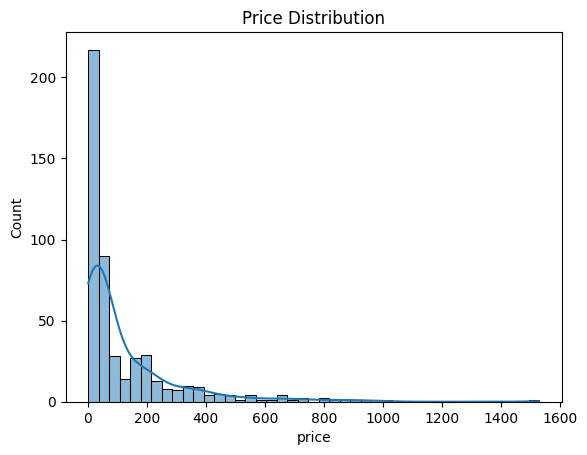

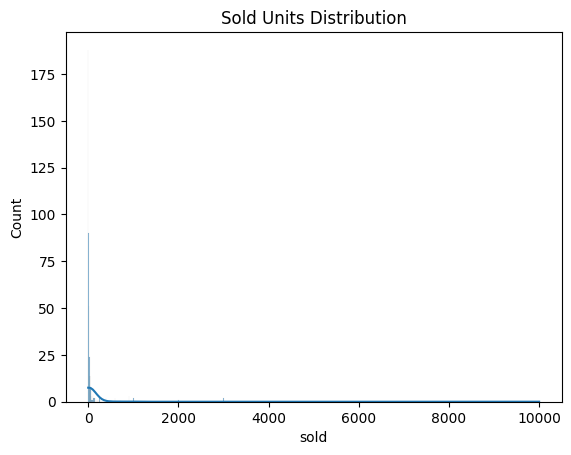

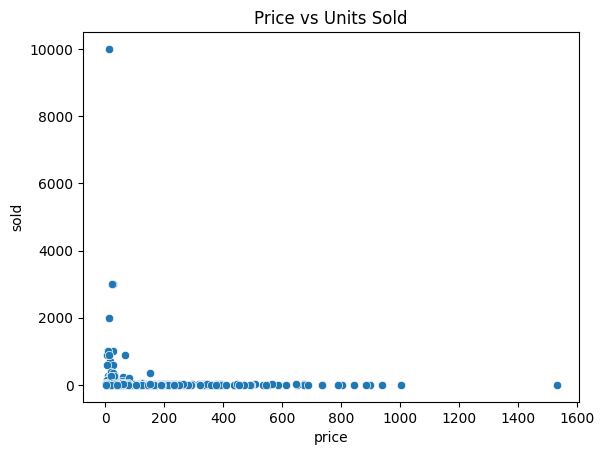

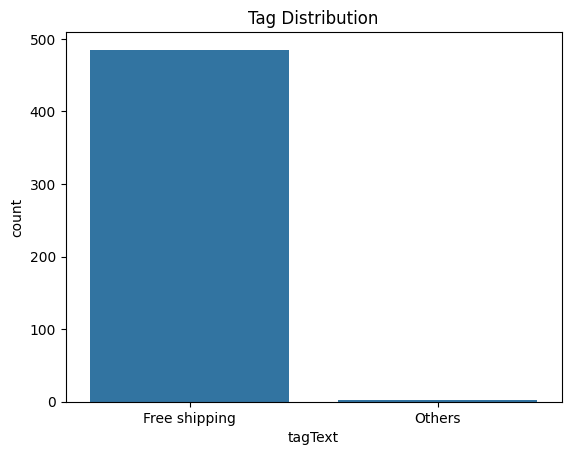

In [13]:
# Price distribution
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

# Sold units distribution
sns.histplot(df['sold'], kde=True)
plt.title("Sold Units Distribution")
plt.show()

# Price vs Sold
sns.scatterplot(x='price', y='sold', data=df)
plt.title("Price vs Units Sold")
plt.show()

# Tag distribution
sns.countplot(x='tagText', data=df)
plt.title("Tag Distribution")
plt.show()


**FEATURE ENGINEERING**

In [14]:
# Discount percentage
df['discount_percent'] = ((df['originalPrice'] - df['price']) / df['originalPrice']) * 100

# Encode tagText
le = LabelEncoder()
df['tagText'] = le.fit_transform(df['tagText'])

# TF-IDF on productTitle
tfidf = TfidfVectorizer(max_features=100)
title_tfidf = tfidf.fit_transform(df['productTitle'])
tfidf_df = pd.DataFrame(title_tfidf.toarray(), columns=tfidf.get_feature_names_out())
df = pd.concat([df.reset_index(drop=True), tfidf_df], axis=1)
df.drop('productTitle', axis=1, inplace=True)


**MODEL BUILDING**

In [15]:
# Features and target
X = df.drop('sold', axis=1)
y = df['sold']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

**MODEL EVALUATION**

In [16]:
# Linear Regression Evaluation
y_pred_lr = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))

# Random Forest Evaluation
y_pred_rf = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))


Linear Regression R2: -0.41508480636067957
Linear Regression MSE: 194750.98709604898
Random Forest R2: 0.2526229683443707
Random Forest MSE: 102857.73262040818


**SQL INTEGRATION**

In [17]:
# Save to SQLite DB
conn = sqlite3.connect("furniture.db")
df.to_sql("furniture_data", conn, if_exists="replace", index=False)

# Sample SQL query
query = "SELECT * FROM furniture_data ORDER BY sold DESC LIMIT 10"
top_selling = pd.read_sql_query(query, conn)
print(top_selling)


   originalPrice  price   sold  tagText  discount_percent  adjustable  \
0          32.07  12.28  10000        0         61.708762    0.000000   
1          49.35  26.11   3000        0         47.092199    0.475036   
2          47.70  21.94   3000        0         54.004193    0.475036   
3          32.72  13.64   2000        0         58.312958    0.000000   
4          56.58  26.03   1000        0         53.994344    0.306330   
5          17.87   8.04   1000        0         55.008394    0.000000   
6          18.32   5.00    900        0         72.707424    0.000000   
7         144.96  66.68    900        0         54.001104    0.641952   
8          30.18  11.20    900        0         62.889331    0.000000   
9          15.40  15.40    700        0          0.000000    0.000000   

        and  bed  bedroom  bedside  ...     under  upholstered  vanity  \
0  0.000000  0.0      0.0      0.0  ...  0.000000          0.0     0.0   
1  0.337869  0.0      0.0      0.0  ...  0.00000

**EXPORT FOR EXCEL Formate File**

In [18]:
# Export cleaned data
df.to_csv("cleaned_furniture_data.csv", index=False)
print("Data exported to cleaned_furniture_data.csv")


Data exported to cleaned_furniture_data.csv
